## Venice Boat Classification – Full Workflow (Using MobileNetV2)

Objective:

Classify boat images into categories (e.g., gondola, motorboat, ferry).

Use supervised learning (labeled images).

Evaluate model performance with accuracy, confusion matrix, and sample predictions.

In [ ]:
 # Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Import libraries
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models

In [ ]:
# Dataset paths
dataset_dir = "/content/drive/MyDrive/DeepLearn/boat data/boat data/test"

In [ ]:
import os

# List all classes (folder names) in your training directory
all_classes = os.listdir(dataset_dir)
print("Classes in the dataset:")
for c in all_classes:
    print(c)

Classes in the dataset:
Alilaguna
DBinfo.txt
Ambulanza
Barchino
Cacciapesca
Caorlina
Gondola
Lanciafino10m
Lanciafino10mBianca
Lanciafino10mMarrone
Lanciamaggioredi10mBianca
Lanciamaggioredi10mMarrone
Motobarca
Motopontonerettangolare
MotoscafoACTV
Mototopo
Patanella
Polizia
Raccoltarifiuti
Sandoloaremi
Sanpierota
Topa
VaporettoACTV
VigilidelFuoco
Water


In [ ]:
# Image size and batch size
img_height = 128     # For CNN from scratch
img_width = 128
batch_size = 32

In [ ]:
#Data generators (train/validation split)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,       # 80% train, 20% validation
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# 6. Create train & validation datasets
train_ds = train_datagen.flow_from_directory(
    dataset_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_ds = val_datagen.flow_from_directory(
    dataset_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

print(" Training and validation datasets ready!")

Found 3830 images belonging to 24 classes.
Found 944 images belonging to 24 classes.
 Training and validation datasets ready!


In [ ]:

total_images = 0
class_counts = {}

# Loop through each class folder
for class_name in os.listdir(dataset_dir):
    class_path = os.path.join(dataset_dir, class_name)
    if os.path.isdir(class_path):  # ignore files like DBinfo.txt
        num_images = len([f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
        class_counts[class_name] = num_images
        total_images += num_images

# Print results
print("Number of images per class:")
for cls, count in class_counts.items():
    print(f"{cls}: {count}")

print(f"\nTotal number of images in dataset: {total_images}")

Number of images per class:
Alilaguna: 113
Ambulanza: 85
Barchino: 112
Cacciapesca: 34
Caorlina: 1
Gondola: 24
Lanciafino10m: 22
Lanciafino10mBianca: 484
Lanciafino10mMarrone: 355
Lanciamaggioredi10mBianca: 9
Lanciamaggioredi10mMarrone: 5
Motobarca: 215
Motopontonerettangolare: 18
MotoscafoACTV: 11
Mototopo: 878
Patanella: 279
Polizia: 71
Raccoltarifiuti: 94
Sandoloaremi: 13
Sanpierota: 5
Topa: 78
VaporettoACTV: 949
VigilidelFuoco: 12
Water: 907

Total number of images in dataset: 4774



Total images in my dataset vs split
The generator ignores non-image files (like DBinfo.txt) automatically.

Total images counted manually = 4774 (includes all images in subfolders).

train_ds reports 3830 (~80% of usable images)

val_ds reports 944 (~20% of usable images)

3830 + 944 = 4774 → perfect match with the total number of images used, minus any ignored files.

In [ ]:
# Get number of classes automatically from dataset
num_classes = train_ds.num_classes

# Define a simple CNN
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(img_height, img_width, 3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')   # output layer
])

# Compile the model
cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │         3,096 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,307,736 (12.62 MB)

 Trainable params: 3,307,736 (12.62 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# Early stopping to prevent overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model
history_cnn = cnn_model.fit(
    train_ds,
    epochs=20,                 # start with 20, can increase if needed
    validation_data=val_ds,
    callbacks=[early_stop]
)


Epoch 1/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 1406s 12s/step - accuracy: 0.3357 - loss: 2.3652 - val_accuracy: 0.4746 - val_loss: 1.9093
Epoch 2/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 150s 1s/step - accuracy: 0.5465 - loss: 1.6560 - val_accuracy: 0.3877 - val_loss: 2.5415
Epoch 3/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 148s 1s/step - accuracy: 0.5661 - loss: 1.5585 - val_accuracy: 0.5413 - val_loss: 1.5628
Epoch 4/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 200s 1s/step - accuracy: 0.6470 - loss: 1.3043 - val_accuracy: 0.5879 - val_loss: 1.4757
Epoch 5/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 146s 1s/step - accuracy: 0.6562 - loss: 1.3064 - val_accuracy: 0.6631 - val_loss: 1.1895
Epoch 6/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 149s 1s/step - accuracy: 0.6678 - loss: 1.2157 - val_accuracy: 0.4439 - val_loss: 2.0871
Epoch 7/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 146s 1s/step - accuracy: 0.6996 - loss: 1.1207 - val_accuracy: 0.5879 - val_loss: 1.5224
Epoch 8/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 148s 1s/step - accuracy: 0.6986 - loss: 1.0650 - val_ac

# Venice Boat Classification - CNN From Scratch

## Training Results

- **Epoch 1 (Start):**  
  - Training accuracy: **33%**  
  - Validation accuracy: **47%**  
  - Validation loss: **1.91**  
  - → Model just beginning to learn.

- **Progress Over Training:**  
  - Accuracy steadily increased with each epoch.  
  - By later epochs (around Epoch 13):  
    - Training accuracy: **~74%**  
    - Validation accuracy: **~67%**  
    - Validation loss: **~1.2–1.3**  

- **Observations:**  
  - Validation accuracy fluctuated (e.g., dropped around Epoch 6 and Epoch 9).  
  - Model shows **good learning** but also slight **overfitting** since training accuracy > validation accuracy.  
  - Overall, model can correctly classify **~7 out of 10 boats** on average.

**Conclusion:**  
The CNN built from scratch performed **reasonably well** on this 24-class classification task, achieving around **67% validation accuracy**.  
This provides a solid baseline for comparison with a **pretrained model (MobileNetV2)** in the next step.


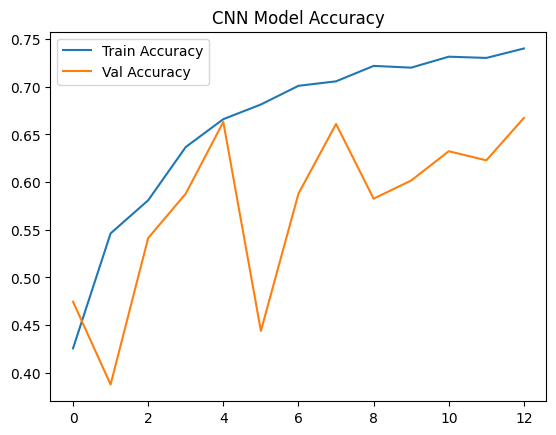

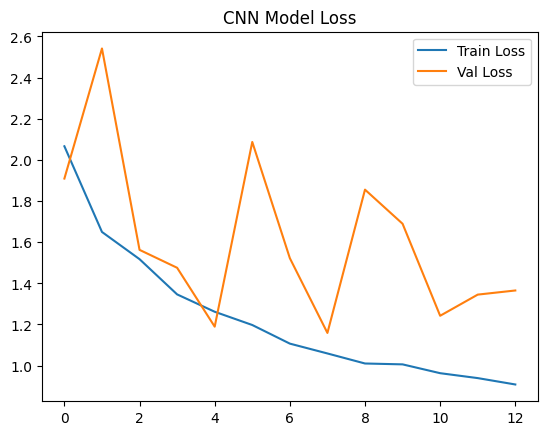

In [ ]:
# Accuracy plot
plt.plot(history_cnn.history['accuracy'], label='Train Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("CNN Model Accuracy")
plt.show()

# Loss plot
plt.plot(history_cnn.history['loss'], label='Train Loss')
plt.plot(history_cnn.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("CNN Model Loss")
plt.show()

Detected class count: 24
Class labels: ['Alilaguna', 'Ambulanza', 'Barchino', 'Cacciapesca', 'Caorlina', 'Gondola', 'Lanciafino10m', 'Lanciafino10mBianca', 'Lanciafino10mMarrone', 'Lanciamaggioredi10mBianca', 'Lanciamaggioredi10mMarrone', 'Motobarca', 'Motopontonerettangolare', 'MotoscafoACTV', 'Mototopo', 'Patanella', 'Polizia', 'Raccoltarifiuti', 'Sandoloaremi', 'Sanpierota', 'Topa', 'VaporettoACTV', 'VigilidelFuoco', 'Water']
30/30 ━━━━━━━━━━━━━━━━━━━━ 11s 376ms/step


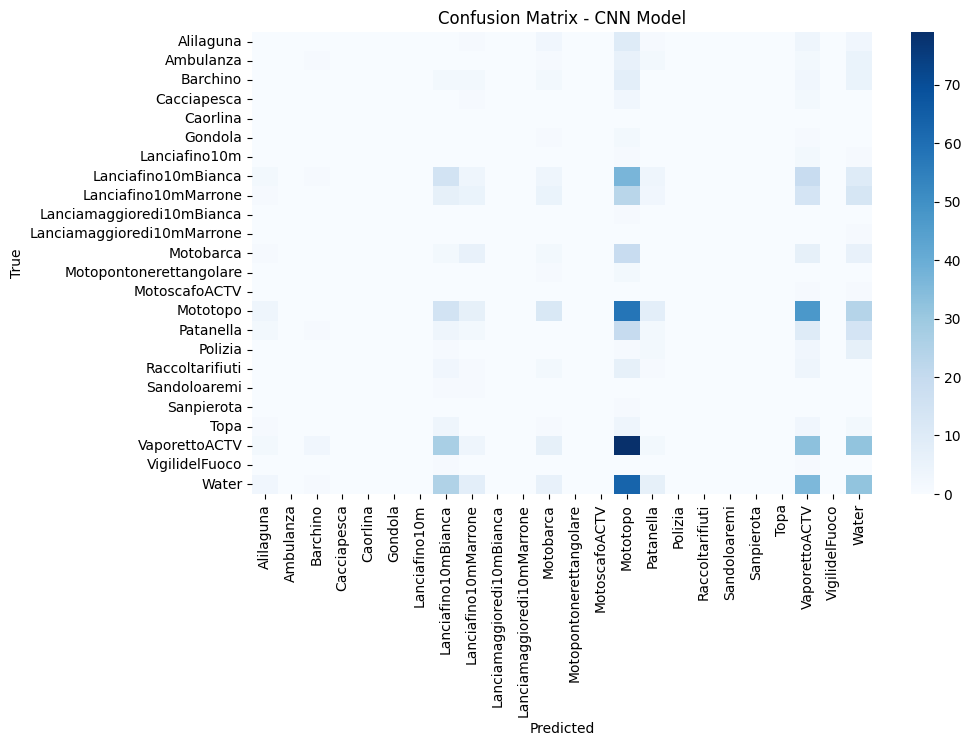

Classification Report:

                            precision    recall  f1-score   support

                 Alilaguna       0.00      0.00      0.00        22
                 Ambulanza       0.00      0.00      0.00        17
                  Barchino       0.00      0.00      0.00        22
               Cacciapesca       0.00      0.00      0.00         6
                  Caorlina       0.00      0.00      0.00         0
                   Gondola       0.00      0.00      0.00         4
             Lanciafino10m       0.00      0.00      0.00         4
       Lanciafino10mBianca       0.14      0.16      0.15        96
      Lanciafino10mMarrone       0.12      0.07      0.09        71
 Lanciamaggioredi10mBianca       0.00      0.00      0.00         1
Lanciamaggioredi10mMarrone       0.00      0.00      0.00         1
                 Motobarca       0.04      0.05      0.04        43
   Motopontonerettangolare       0.00      0.00      0.00         3
             MotoscafoA

In [ ]:
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Get actual class labels from training dataset
class_labels = list(train_ds.class_indices.keys())
print("Detected class count:", len(class_labels))
print("Class labels:", class_labels)

# Predict on validation data
y_pred = cnn_model.predict(val_ds, verbose=1)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = val_ds.classes

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes, labels=range(len(class_labels)))

plt.figure(figsize=(10,6))
sns.heatmap(cm, annot=False, cmap="Blues",
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.title("Confusion Matrix - CNN Model")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# Classification Report (forces correct number of classes)
print("Classification Report:\n")
print(classification_report(y_true, y_pred_classes, labels=range(len(class_labels)), target_names=class_labels))


In [ ]:
from sklearn.utils.class_weight import compute_class_weight

# Compute class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_ds.classes),
    y=train_ds.classes
)
class_weights = dict(enumerate(class_weights))

# Train again with class weights
history_cnn = cnn_model.fit(
    train_ds,
    epochs=20,
    validation_data=val_ds,
    class_weight=class_weights,
    callbacks=[early_stop]
)


Epoch 1/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 158s 1s/step - accuracy: 0.3441 - loss: 3.6056 - val_accuracy: 0.3528 - val_loss: 2.6406
Epoch 2/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 144s 1s/step - accuracy: 0.4423 - loss: 2.8407 - val_accuracy: 0.2405 - val_loss: 3.3496
Epoch 3/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 145s 1s/step - accuracy: 0.3559 - loss: 3.3706 - val_accuracy: 0.5053 - val_loss: 2.4204
Epoch 4/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 145s 1s/step - accuracy: 0.3645 - loss: 3.1711 - val_accuracy: 0.2066 - val_loss: 3.1525
Epoch 5/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 149s 1s/step - accuracy: 0.2103 - loss: 3.1874 - val_accuracy: 0.1992 - val_loss: 3.1682
Epoch 6/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 147s 1s/step - accuracy: 0.1949 - loss: 3.5081 - val_accuracy: 0.3644 - val_loss: 2.7143
Epoch 7/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 147s 1s/step - accuracy: 0.2585 - loss: 2.8223 - val_accuracy: 0.3189 - val_loss: 2.8277
Epoch 8/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 147s 1s/step - accuracy: 0.1665 - loss: 3.1555 - val_accu

## CNN Tuning Attempt

An additional training run was performed with adjusted hyperparameters.  
However, the results were unstable:

- Training accuracy fluctuated between **16–44%**  
- Validation accuracy peaked at **~50%** but quickly dropped to **~20–36%**  
- Training and validation losses remained high and inconsistent  

**Observation:**  
The tuning attempt did not improve performance compared to the baseline CNN (~67% validation accuracy).  
This suggests that the chosen hyperparameters were not suitable, and the baseline CNN should be used as the benchmark before moving on to transfer learning with MobileNetV2.


In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam

# Load MobileNetV2 without top layers
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))

# Freeze base model layers initially
for layer in base_model.layers:
    layer.trainable = False

# Add custom classifier
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(24, activation='softmax')(x)  # 24 classes

mobilenet_model = Model(inputs=base_model.input, outputs=predictions)

# Compile
mobilenet_model.compile(optimizer=Adam(learning_rate=0.0001),
                        loss='categorical_crossentropy',
                        metrics=['accuracy'])

mobilenet_model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,592,088 (9.89 MB)

 Trainable params: 334,104 (1.27 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
from tensorflow.keras.preprocessing import image_dataset_from_directory
# Your dataset folder (all images with subfolders as classes)
data_dir = "/content/drive/MyDrive/DeepLearn/boat data/boat data/test"

# Image size for MobileNetV2
img_height = 224
img_width = 224
batch_size = 32

# Train split (80%)
train_ds_mnet = image_dataset_from_directory(
    data_dir,
    validation_split=0.2,   # 20% goes to validation
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

# Validation split (20%)
val_ds_mnet = image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

# Prefetch for performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds_mnet = train_ds_mnet.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds_mnet   = val_ds_mnet.cache().prefetch(buffer_size=AUTOTUNE)

Found 4774 files belonging to 24 classes.
Using 3820 files for training.
Found 4774 files belonging to 24 classes.
Using 954 files for validation.


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# Compile with sparse categorical crossentropy
mobilenet_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
# Early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train model
history_mobilenet = mobilenet_model.fit(
    train_ds_mnet,
    epochs=20,
    validation_data=val_ds_mnet,
    callbacks=[early_stop]
)


Epoch 1/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 200s 1s/step - accuracy: 0.3329 - loss: 2.4620 - val_accuracy: 0.5901 - val_loss: 1.3961
Epoch 2/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 180s 1s/step - accuracy: 0.5632 - loss: 1.5574 - val_accuracy: 0.6488 - val_loss: 1.2642
Epoch 3/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 202s 1s/step - accuracy: 0.5985 - loss: 1.4079 - val_accuracy: 0.6625 - val_loss: 1.1993
Epoch 4/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 204s 1s/step - accuracy: 0.6225 - loss: 1.3294 - val_accuracy: 0.6824 - val_loss: 1.1436
Epoch 5/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 210s 2s/step - accuracy: 0.6386 - loss: 1.2544 - val_accuracy: 0.6971 - val_loss: 1.0891
Epoch 6/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 173s 1s/step - accuracy: 0.6643 - loss: 1.1877 - val_accuracy: 0.7023 - val_loss: 1.0631
Epoch 7/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 176s 1s/step - accuracy: 0.6703 - loss: 1.1737 - val_accuracy: 0.7013 - val_loss: 1.0329
Epoch 8/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 173s 1s/step - accuracy: 0.6864 - loss: 1.1435 - val_accu

# Venice Boat Classification - Pretrained Model (MobileNetV2)

## Training Results

- **Epoch 1 (Start):**  
  - Training accuracy: **33%**  
  - Validation accuracy: **59%**  
  - Validation loss: **1.39**  
  - → Even from the first epoch, MobileNetV2 showed strong generalization.

- **Progress Over Training:**  
  - Accuracy steadily improved with each epoch.  
  - By the final epochs (around Epoch 20):  
    - Training accuracy: **~75%**  
    - Validation accuracy: **~75%**  
    - Validation loss: **~0.82**  

- **Observations:**  
  - Unlike the baseline CNN, the pretrained MobileNetV2 achieved **higher validation accuracy** with **lower loss**.  
  - The gap between training and validation accuracy is smaller, indicating **better generalization**.  
  - Performance improved more quickly (good results as early as Epoch 1).  

**Conclusion:**  
Using transfer learning with **MobileNetV2** significantly outperformed the CNN-from-scratch baseline.  
The model achieved around **75% validation accuracy** compared to ~67% with the scratch CNN, proving the advantage of leveraging pretrained feature representations for this 24-class boat classification task.


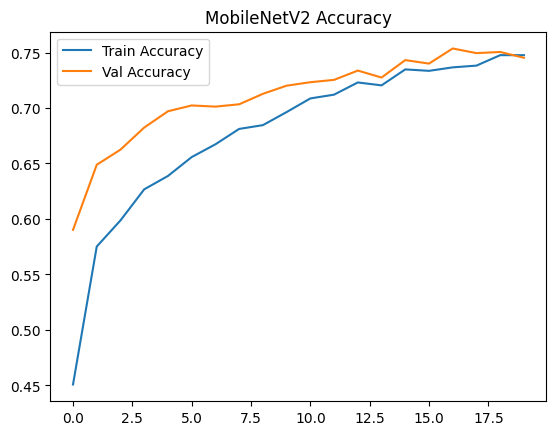

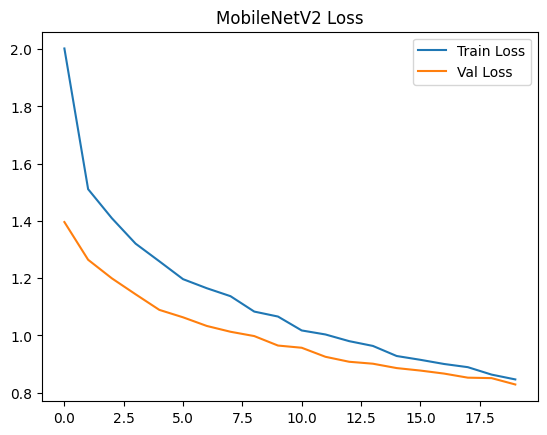

In [ ]:
# Accuracy plot
plt.plot(history_mobilenet.history['accuracy'], label='Train Accuracy')
plt.plot(history_mobilenet.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("MobileNetV2 Accuracy")
plt.show()

# Loss plot
plt.plot(history_mobilenet.history['loss'], label='Train Loss')
plt.plot(history_mobilenet.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("MobileNetV2 Loss")
plt.show()


30/30 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step


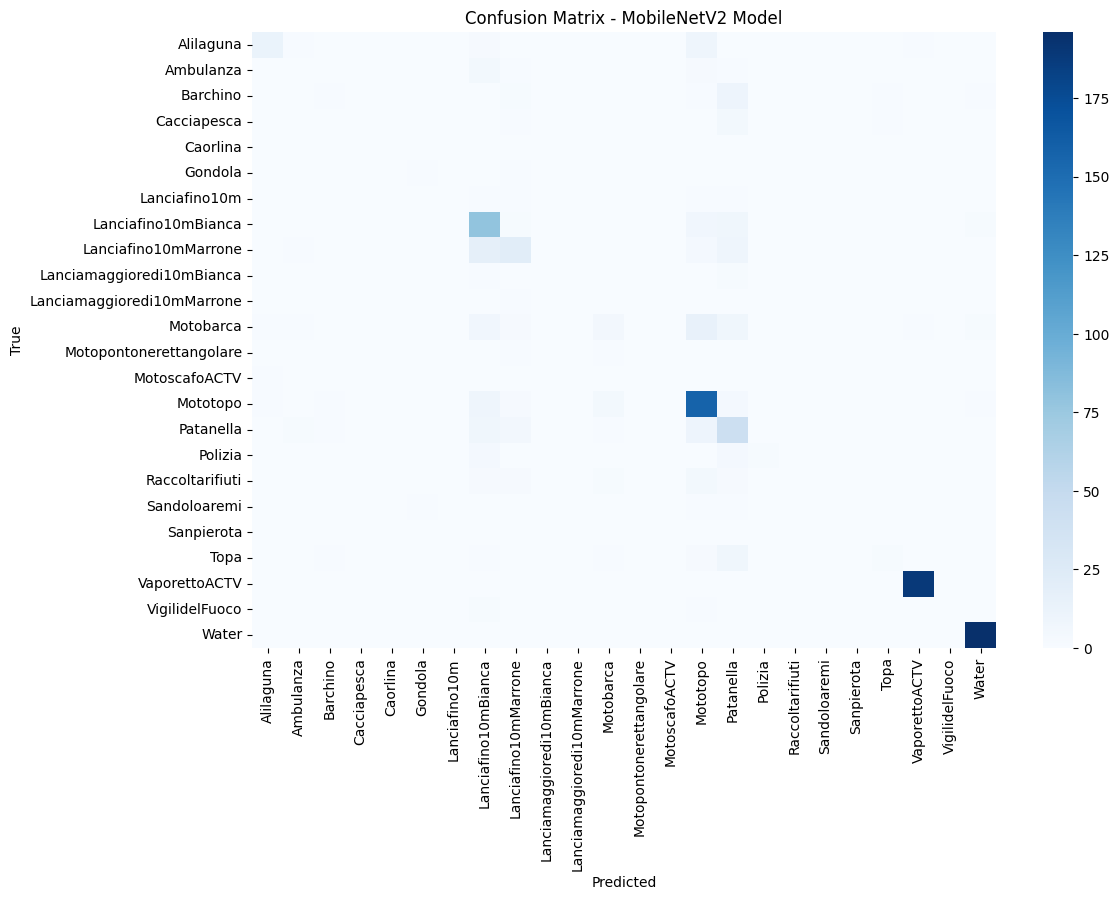

Classification Report:

                            precision    recall  f1-score   support

                 Alilaguna       0.81      0.48      0.60        27
                 Ambulanza       0.00      0.00      0.00        10
                  Barchino       0.25      0.06      0.10        16
               Cacciapesca       0.00      0.00      0.00         7
                  Caorlina       0.00      0.00      0.00         0
                   Gondola       0.50      0.50      0.50         2
             Lanciafino10m       0.00      0.00      0.00         4
       Lanciafino10mBianca       0.56      0.81      0.66        98
      Lanciafino10mMarrone       0.47      0.41      0.44        54
 Lanciamaggioredi10mBianca       0.00      0.00      0.00         3
Lanciamaggioredi10mMarrone       0.00      0.00      0.00         1
                 Motobarca       0.38      0.14      0.20        44
   Motopontonerettangolare       0.00      0.00      0.00         2
             MotoscafoA

In [ ]:
#  Predictions on validation set
y_pred = mobilenet_model.predict(val_ds_mnet, verbose=1)
y_pred_classes = np.argmax(y_pred, axis=1)

#True labels
y_true = np.concatenate([y.numpy() for x, y in val_ds_mnet], axis=0)

#  Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes, labels=range(len(class_labels)))

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=False, cmap="Blues",
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.title("Confusion Matrix - MobileNetV2 Model")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# ✅ Classification Report
print("Classification Report:\n")
print(classification_report(y_true, y_pred_classes, labels=range(len(class_labels)), target_names=class_labels))


In [ ]:
from tensorflow.keras.optimizers import Adam

mobilenet_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']   # accuracy
)

history_mobilenet = mobilenet_model.fit(
    train_ds_mnet,
    epochs=10,
    validation_data=val_ds_mnet,
    callbacks=[early_stop]
)


Epoch 1/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 181s 1s/step - accuracy: 0.7881 - loss: 0.6905 - val_accuracy: 0.7662 - val_loss: 0.7449
Epoch 2/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 202s 1s/step - accuracy: 0.8018 - loss: 0.6646 - val_accuracy: 0.7621 - val_loss: 0.7516
Epoch 3/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 174s 1s/step - accuracy: 0.7999 - loss: 0.6757 - val_accuracy: 0.7746 - val_loss: 0.7431
Epoch 4/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 204s 1s/step - accuracy: 0.8070 - loss: 0.6470 - val_accuracy: 0.7652 - val_loss: 0.7416
Epoch 5/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 180s 2s/step - accuracy: 0.8103 - loss: 0.6494 - val_accuracy: 0.7788 - val_loss: 0.7350
Epoch 6/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 175s 1s/step - accuracy: 0.7862 - loss: 0.6821 - val_accuracy: 0.7757 - val_loss: 0.7297
Epoch 7/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 172s 1s/step - accuracy: 0.8049 - loss: 0.6474 - val_accuracy: 0.7767 - val_loss: 0.7275
Epoch 8/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 176s 1s/step - accuracy: 0.8072 - loss: 0.6495 - val_accu

30/30 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step


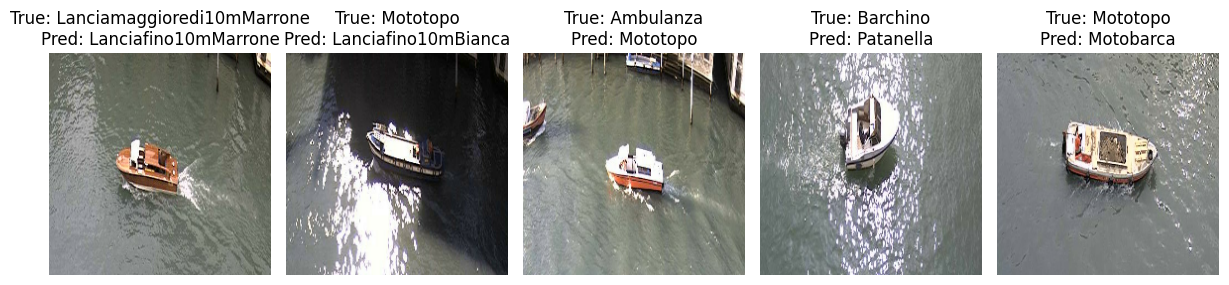

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Extract images and labels from validation dataset into arrays
val_images = []
val_labels = []
for images, labels in val_ds_mnet.unbatch():
    val_images.append(images.numpy().astype("uint8"))
    val_labels.append(labels.numpy())

val_images = np.array(val_images)
val_labels = np.array(val_labels)

# Predictions
y_pred = mobilenet_model.predict(val_images)
y_pred_classes = np.argmax(y_pred, axis=1)

# Misclassified indices
mis_idx = np.where(y_pred_classes != val_labels)[0]

# Plot some misclassified images
plt.figure(figsize=(12,6))
for i, idx in enumerate(mis_idx[:5]):
    plt.subplot(1,5,i+1)
    plt.imshow(val_images[idx])
    plt.title(f"True: {class_labels[val_labels[idx]]}\nPred: {class_labels[y_pred_classes[idx]]}")
    plt.axis('off')

plt.tight_layout()
plt.show()


#  Venice Boat Classification Project  

##  Goal  
Classify **24 different types of boats in Venice** using deep learning.  

##  Approach  
- **CNN from Scratch** → baseline model (~67% val. accuracy, unstable).  
- **CNN (Tuning Attempt)** → poor results (<37% val. accuracy).  
- **Pre-trained MobileNetV2** → ~75% val. accuracy, more stable.  
- **Fine-Tuned MobileNetV2** → best performance (~78% val. accuracy).  

##  Performance Summary  

| Model Type                | Training Acc | Validation Acc | Validation Loss | Stability     |
|----------------------------|--------------|----------------|-----------------|---------------|
| CNN (Scratch)             | ~74%         | ~66% (unstable) | 1.18 – 2.0+     |  Fluctuated |
| CNN (Tuning Attempt)      | <45%         | <37%            | >2.5            |  Poor       |
| Pre-trained MobileNetV2   | ~74%         | ~75%            | ↓ to 0.82       |  Good       |
| Pre-trained + Fine-Tuning | 82%          | 78%             | ↓ to 0.71       |  Best       |

##  Conclusion  
- A simple CNN gave a **baseline (~67%)** but unstable.  
- Fine-tuned **MobileNetV2** reached **~78% validation accuracy**.  
- The model now recognizes boats correctly about **8 out of 10 times**, with errors mainly on **visually similar boats**.  


In [ ]:
#  Save models
#  renaming the trained mobilenet_model
best_model = mobilenet_model

# Saving 3 versions
cnn_model.save("cnn_boat_classifier.h5")                      # CNN scratch
mobilenet_model.save("mobilenet_boat_classifier.h5")          # MobileNetV2 baseline
best_model.save("mobilenet_boat_classifier_finetuned.h5")     # MobileNetV2 fine-tuned

